# Module 6 - Vehicle Verification & Anomaly Detection

## Overview

This notebook covers the vehicle verification and anomaly detection phase of the Driver Monitoring AI project. We built a multi-signal pipeline to detect suspicious vehicles using image forensics, OCR plate extraction, and deep learning classification. The pipeline processes truck images and highway traffic footage to assign a suspicion score and risk tier to each vehicle.

## Datasets Used

| Dataset | Rows / Entries | Columns | File |
|---|---|---|---|
| YOLO Truck Images | 1,002 images | — (folder-based) | Yolo Truck Datasets/ |
| Highway Traffic Patches | 254 sequences × 48 frames | — (MATLAB) | traffic_patches.mat |
| Delivery Truck Trips | 1,159 vehicles | 17 | delivery_trucks_cleaned.csv |
| Synthetic Licenses | 40 images | — (generated) | data/licenses/ |

## Models Built

- **OpenCV Image Forensics** — blur score, noise score, and edge density analysis for anomaly flagging
- **Tesseract OCR Pipeline** — contour-based plate region detection with alphanumeric extraction
- **MobileNetV2 CNN Classifier** — transfer learning binary classifier (truck vs suspicious vehicle), 88% test accuracy
- **Ensemble Suspicion Scorer** — weighted combination of OCR confidence (25%), CNN score (55%), and forensics flag (20%) into LOW / MEDIUM / HIGH risk tiers

In [1]:
# Module 6 — Vehicle Verification & Anomaly Detection

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import cv2
import scipy.io
import pytesseract
import importlib.util
import sys
from pathlib import Path

warnings.filterwarnings("ignore")

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

print(f"TensorFlow : {tf.__version__}")
print(f"OpenCV     : {cv2.__version__}")
print(f"GPU        : {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow : 2.20.0
OpenCV     : 4.13.0
GPU        : False


In [2]:
# Paths
YOLO_BASE    = Path("../Yolo Truck Datasets/images.cv_i22cy7ksd1je11zjz4boze/data")
YOLO_TRAIN   = YOLO_BASE / "train"
YOLO_VAL     = YOLO_BASE / "val"
YOLO_TEST    = YOLO_BASE / "test"

TRAFFIC_BASE = Path("../Highway Traffic Videos")
TRAFFIC_MAT  = TRAFFIC_BASE / "traffic_patches.mat"

OUTPUT_DIR   = Path("../outputs/module6")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for p, name in [
    (YOLO_TRAIN,  "YOLO Train"),
    (YOLO_VAL,    "YOLO Val"),
    (YOLO_TEST,   "YOLO Test"),
    (TRAFFIC_MAT, "Traffic .mat"),
]:
    status = "found" if p.exists() else "NOT FOUND"
    print(f"[{status}]  {name}: {p}")

[found]  YOLO Train: ..\Yolo Truck Datasets\images.cv_i22cy7ksd1je11zjz4boze\data\train
[found]  YOLO Val: ..\Yolo Truck Datasets\images.cv_i22cy7ksd1je11zjz4boze\data\val
[found]  YOLO Test: ..\Yolo Truck Datasets\images.cv_i22cy7ksd1je11zjz4boze\data\test
[found]  Traffic .mat: ..\Highway Traffic Videos\traffic_patches.mat


In [3]:
# Step 1: Data Loading & EDA

def count_images(split_path):
    counts = {}
    for class_dir in sorted(split_path.iterdir()):
        if not class_dir.is_dir() or class_dir.name.startswith('.'):
            continue
        imgs      = list(class_dir.glob("*.jpg"))
        originals = [f for f in imgs if "_aug" not in f.stem]
        augmented = [f for f in imgs if "_aug" in f.stem]
        counts[class_dir.name] = {
            "total": len(imgs), "original": len(originals), "augmented": len(augmented)
        }
    return counts

splits    = {"train": YOLO_TRAIN, "val": YOLO_VAL, "test": YOLO_TEST}
inventory = {split: count_images(path) for split, path in splits.items()}

CLASS_NAMES  = ["truck", "vehicle truck"]
CLASS_LABELS = {name: idx for idx, name in enumerate(CLASS_NAMES)}

print("YOLO Truck Dataset")
print("=" * 50)
for split, classes in inventory.items():
    print(f"\n  [{split.upper()}]")
    for cls, info in classes.items():
        print(f"    {cls:20s} -> {info['total']:4d}  ({info['original']} orig + {info['augmented']} aug)")
print(f"\nLabels: {CLASS_LABELS}")

YOLO Truck Dataset

  [TRAIN]
    truck                ->  663  (393 orig + 270 aug)
    vehicle truck        ->   65  (38 orig + 27 aug)

  [VAL]
    truck                ->  182  (182 orig + 0 aug)
    vehicle truck        ->    7  (7 orig + 0 aug)

  [TEST]
    truck                ->   79  (79 orig + 0 aug)
    vehicle truck        ->    6  (6 orig + 0 aug)

Labels: {'truck': 0, 'vehicle truck': 1}


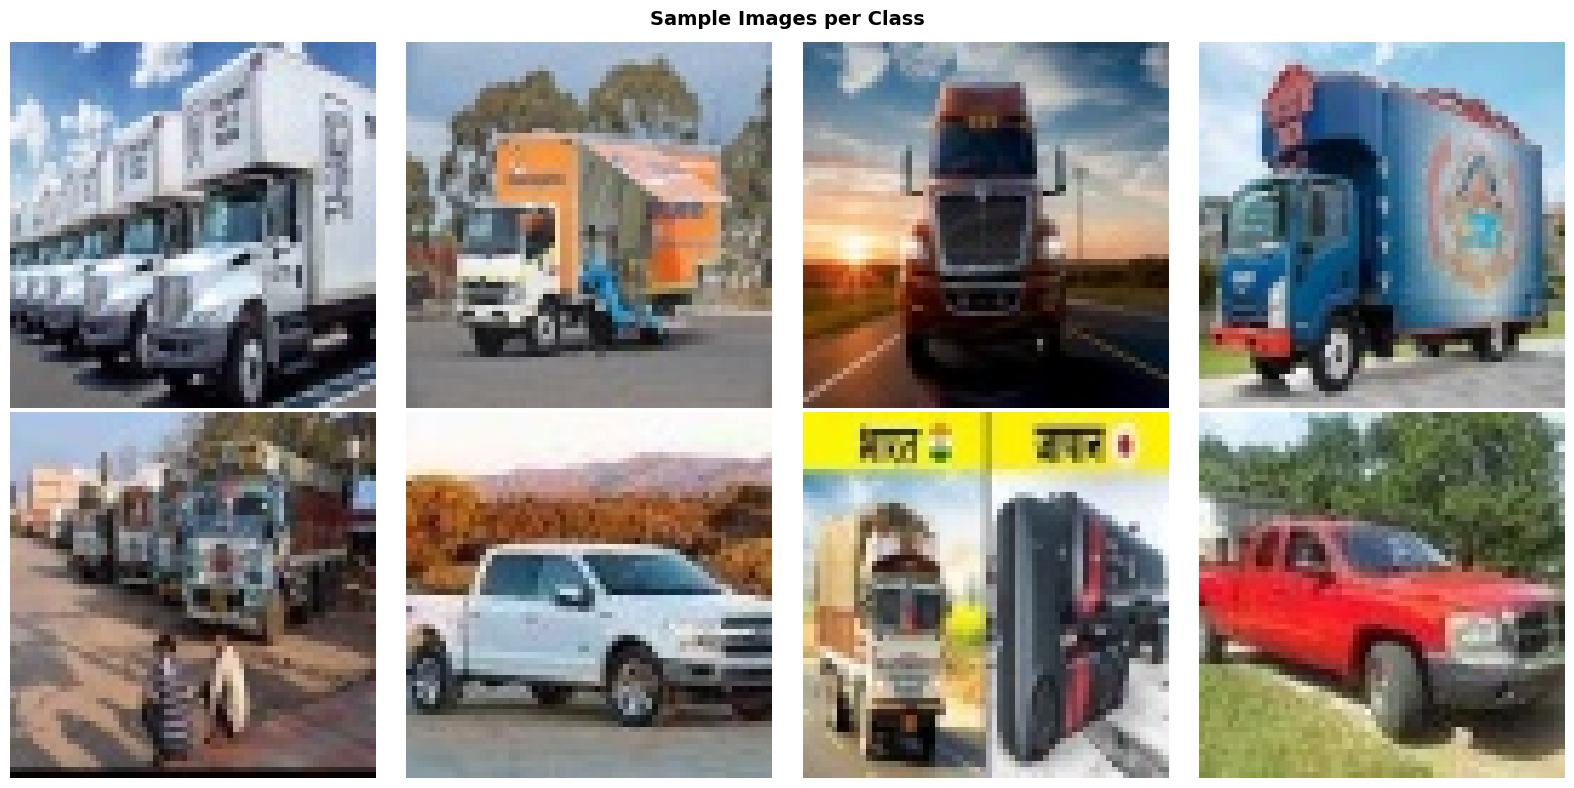

In [4]:
# Sample images per class

def load_sample_images(split_path, n=4):
    samples = {}
    for class_dir in sorted(split_path.iterdir()):
        if not class_dir.is_dir() or class_dir.name.startswith('.'):
            continue
        if class_dir.name not in CLASS_NAMES:
            continue
        imgs   = [f for f in class_dir.glob("*.jpg") if "_aug" not in f.stem]
        loaded = []
        for p in imgs:
            img = cv2.imread(str(p))
            if img is not None:
                loaded.append(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            if len(loaded) == n:
                break
        samples[class_dir.name] = loaded
    return samples

samples = load_sample_images(YOLO_TRAIN)

fig, axes = plt.subplots(len(samples), 4, figsize=(16, 4 * len(samples)))
fig.suptitle("Sample Images per Class", fontsize=14, fontweight='bold')

for row, (cls_name, imgs) in enumerate(samples.items()):
    for col in range(4):
        ax = axes[row][col] if len(samples) > 1 else axes[col]
        if col < len(imgs):
            ax.imshow(imgs[col])
        else:
            ax.text(0.5, 0.5, "N/A", ha='center', va='center', fontsize=12)
        ax.axis("off")
        if col == 0:
            ax.set_ylabel(f"[{CLASS_LABELS[cls_name]}] {cls_name}",
                          fontsize=10, fontweight='bold', rotation=90, labelpad=60)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "step1_sample_images.png", dpi=150, bbox_inches='tight')
plt.show()

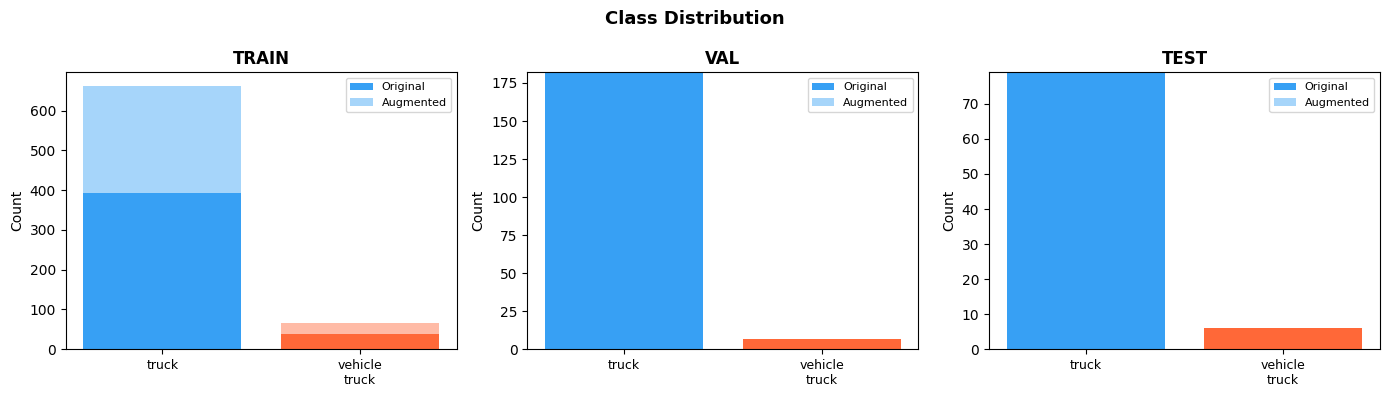

In [5]:
# Class distribution across splits

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Class Distribution", fontsize=13, fontweight='bold')

colors = {"truck": "#2196F3", "vehicle truck": "#FF5722"}

for ax, (split, classes) in zip(axes, inventory.items()):
    cls_names   = [c for c in classes.keys() if c in CLASS_NAMES]
    orig_counts = [classes[c]["original"]  for c in cls_names]
    aug_counts  = [classes[c]["augmented"] for c in cls_names]
    x = np.arange(len(cls_names))

    ax.bar(x, orig_counts, color=[colors[c] for c in cls_names], alpha=0.9, label="Original")
    ax.bar(x, aug_counts,  color=[colors[c] for c in cls_names], alpha=0.4,
           bottom=orig_counts, label="Augmented")
    ax.set_title(split.upper(), fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([c.replace(" ", "\n") for c in cls_names], fontsize=9)
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "step1_class_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# Load Highway Traffic dataset

mat  = scipy.io.loadmat(str(TRAFFIC_MAT))
keys = [k for k in mat.keys() if not k.startswith("__")]
print(f"Keys: {keys}")
for k in keys:
    print(f"  '{k}' -> shape {mat[k].shape}, dtype {mat[k].dtype}")

Keys: ['imgdb']
  'imgdb' -> shape (1, 254), dtype object


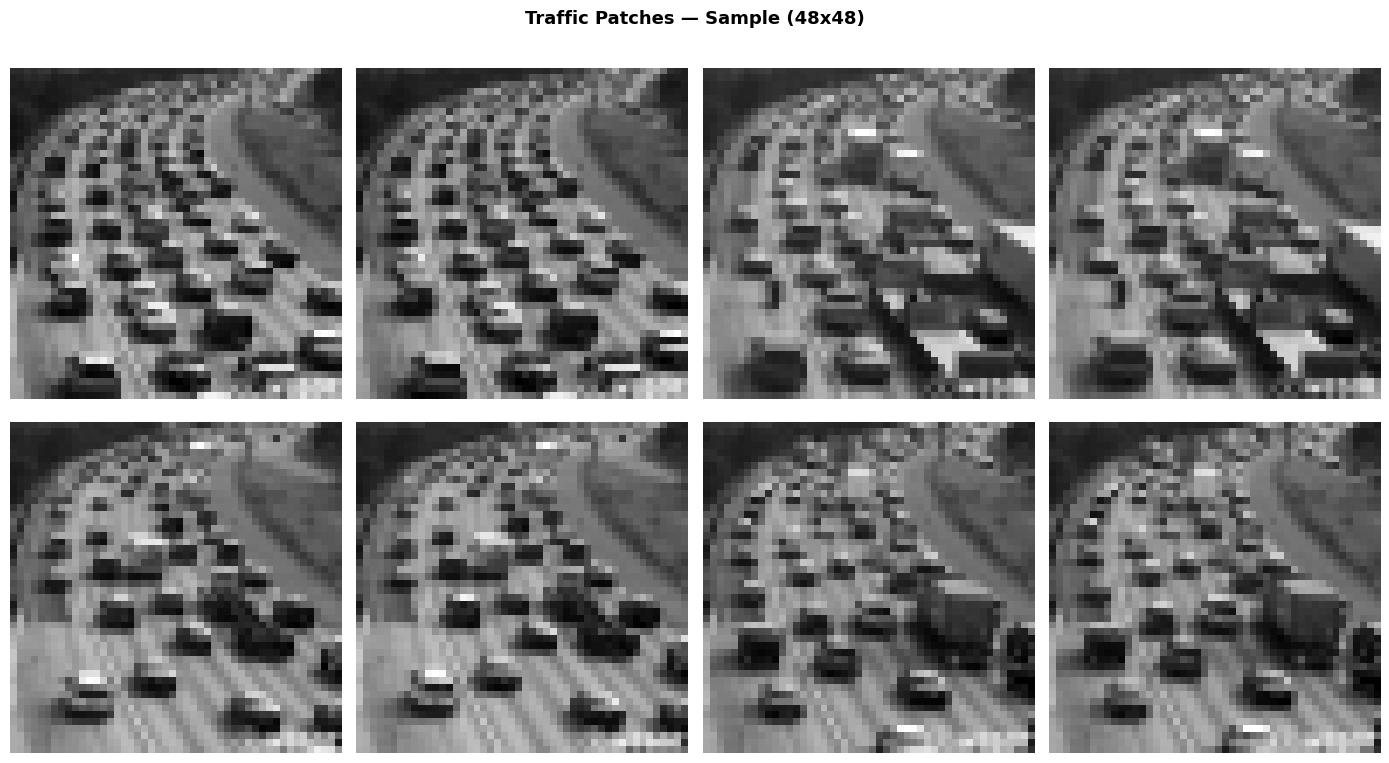

Displayed 8 patches | entry shape: (48, 48, 48)


In [7]:
# Display sample traffic patches
# Each imgdb entry is (48, 48, 48): a stack of 48 grayscale 48x48 frames

imgdb = mat['imgdb']

sample_patches = []
for i in range(min(4, imgdb.shape[1])):
    stack = imgdb[0, i]
    for j in range(min(2, stack.shape[2])):
        sample_patches.append(stack[:, :, j])

n    = len(sample_patches)
cols = min(4, n)
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(14, 4 * rows))
axes = np.array(axes).flatten()
fig.suptitle("Traffic Patches — Sample (48x48)", fontsize=13, fontweight='bold')

for ax, patch in zip(axes, sample_patches):
    p = patch.astype(np.float32)
    p = (p - p.min()) / (p.max() - p.min() + 1e-8)
    ax.imshow(p, cmap='gray')
    ax.axis("off")
for ax in axes[n:]:
    ax.axis("off")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "step1_traffic_patches.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Displayed {n} patches | entry shape: {imgdb[0,0].shape}")

In [8]:
# Step 2: Image Forensics

def blur_score(img_gray):
    return cv2.Laplacian(img_gray, cv2.CV_64F).var()

def noise_score(img_gray):
    blurred = cv2.GaussianBlur(img_gray, (5, 5), 0)
    return float(cv2.absdiff(img_gray, blurred).astype(np.float32).mean())

def edge_density(img_gray):
    edges = cv2.Canny(img_gray, 50, 150)
    return edges.sum() / (edges.shape[0] * edges.shape[1] * 255)

In [9]:
# Compute blur, noise, edge density for all truck images

records = []
for split_name, split_path in splits.items():
    for class_dir in sorted(split_path.iterdir()):
        if not class_dir.is_dir() or class_dir.name not in CLASS_NAMES:
            continue
        imgs = [f for f in class_dir.glob("*.jpg") if "_aug" not in f.stem]
        for p in imgs:
            img = cv2.imread(str(p))
            if img is None:
                continue
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            records.append({
                "split": split_name, "class": class_dir.name,
                "label": CLASS_LABELS[class_dir.name], "filename": p.name,
                "blur": blur_score(gray), "noise": noise_score(gray),
                "edge_density": edge_density(gray),
                "height": img.shape[0], "width": img.shape[1],
            })

truck_df = pd.DataFrame(records)
print(f"Analysed {len(truck_df)} images")
print(truck_df.groupby(["split","class"])[["blur","noise","edge_density"]].mean().round(3))

Analysed 705 images
                         blur   noise  edge_density
split class                                        
test  truck          4235.941  11.615         0.227
      vehicle truck  4416.669  11.900         0.200
train truck          3877.667  10.878         0.220
      vehicle truck  3404.204  10.110         0.203
val   truck          3709.106  10.648         0.219
      vehicle truck  4239.867  12.321         0.232


In [10]:
# Flag outliers using mean +/- 2 standard deviations

BLUR_THRESHOLD  = truck_df["blur"].mean()  - 2 * truck_df["blur"].std()
NOISE_THRESHOLD = truck_df["noise"].mean() + 2 * truck_df["noise"].std()

truck_df["blur_flag"]  = truck_df["blur"]  < BLUR_THRESHOLD
truck_df["noise_flag"] = truck_df["noise"] > NOISE_THRESHOLD
truck_df["anomaly"]    = truck_df["blur_flag"] | truck_df["noise_flag"]

n_flagged = truck_df["anomaly"].sum()
print(f"Blur threshold  (mean - 2std): {BLUR_THRESHOLD:.1f}")
print(f"Noise threshold (mean + 2std): {NOISE_THRESHOLD:.1f}")
print(f"Flagged: {n_flagged} / {len(truck_df)} ({100*n_flagged/len(truck_df):.1f}%)")
print(truck_df[truck_df["anomaly"]][["split","class","filename","blur","noise"]].head(10))

Blur threshold  (mean - 2std): 654.3
Noise threshold (mean + 2std): 16.6
Flagged: 19 / 705 (2.7%)
     split  class          filename         blur      noise
12   train  truck  0S13Q5SMF9A4.jpg  5645.040632  16.946533
18   train  truck  1KW939AD5M45.jpg  8307.935291  18.914307
24   train  truck  2118TFG3M10P.jpg  9932.038339  19.291748
62   train  truck  5WWY8X7HXEVO.jpg  8285.868330  18.903564
121  train  truck  BMUG33NB8YP6.jpg  9031.674555  17.153076
122  train  truck  BNE4VL8FI6Z2.jpg  7167.244307  17.770020
141  train  truck  DO91S48WI0RS.jpg  8423.605544  17.650879
160  train  truck  ETIT9YUJA5J8.jpg  8283.921900  19.423340
162  train  truck  EUVSFP14N8HL.jpg  7192.558861  17.929932
172  train  truck  FJZITJNSA7U3.jpg  7473.227190  16.930908


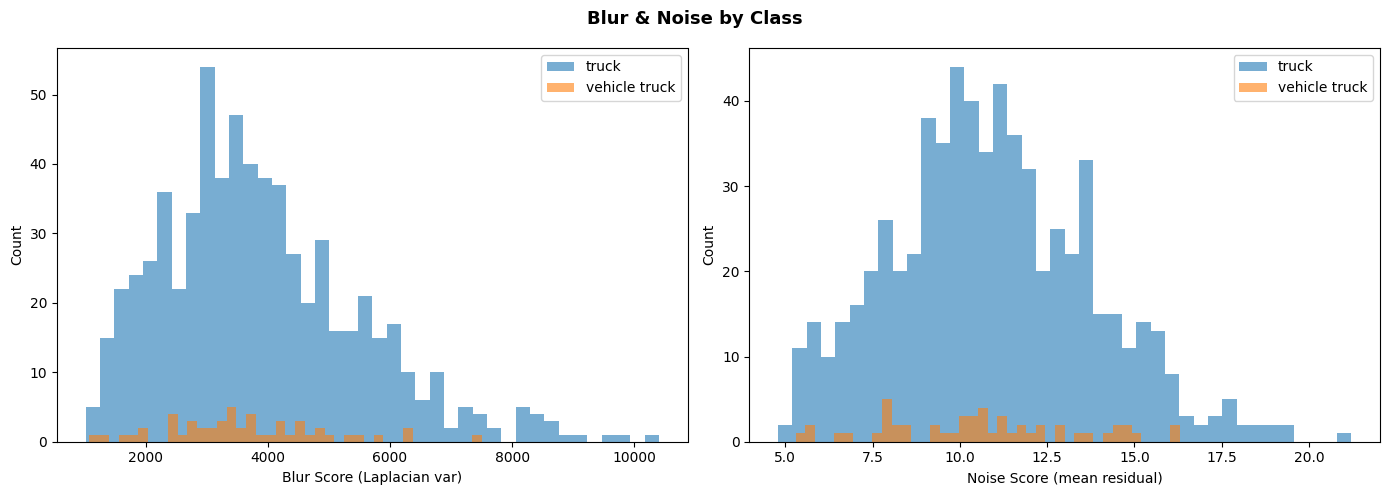

In [11]:
# Blur and noise distribution by class

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Blur & Noise by Class", fontsize=13, fontweight='bold')

for ax, col, label in zip(axes,
                           ["blur", "noise"],
                           ["Blur Score (Laplacian var)", "Noise Score (mean residual)"]):
    for cls, grp in truck_df.groupby("class"):
        ax.hist(grp[col], bins=40, alpha=0.6, label=cls)
    ax.set_xlabel(label)
    ax.set_ylabel("Count")
    ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "step2_truck_forensics.png", dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# Blur variance across traffic sequences

traffic_records = []
for i in range(imgdb.shape[1]):
    stack = imgdb[0, i]
    blurs = [blur_score(stack[:, :, j]) for j in range(stack.shape[2])]
    traffic_records.append({
        "entry_idx": i,
        "blur_mean": np.mean(blurs), "blur_std": np.std(blurs), "blur_min": np.min(blurs),
        "brightness_mean": stack.mean(), "brightness_std": stack.std(),
    })

traffic_df = pd.DataFrame(traffic_records)
print(traffic_df.describe().round(3))

       entry_idx  blur_mean  blur_std  blur_min  brightness_mean  \
count    254.000    254.000   254.000   254.000          254.000   
mean     126.500   2194.747   170.982  1893.517          159.897   
std       73.468   1252.062    70.045  1157.105           21.654   
min        0.000    620.246    26.385   446.831           96.521   
25%       63.250   1186.284   123.154   996.397          147.913   
50%      126.500   1861.757   161.176  1589.374          163.223   
75%      189.750   2796.653   210.428  2479.831          176.874   
max      253.000   6497.576   511.967  6131.740          197.629   

       brightness_std  
count         254.000  
mean           33.407  
std             5.614  
min            22.166  
25%            29.413  
50%            32.685  
75%            37.510  
max            47.245  


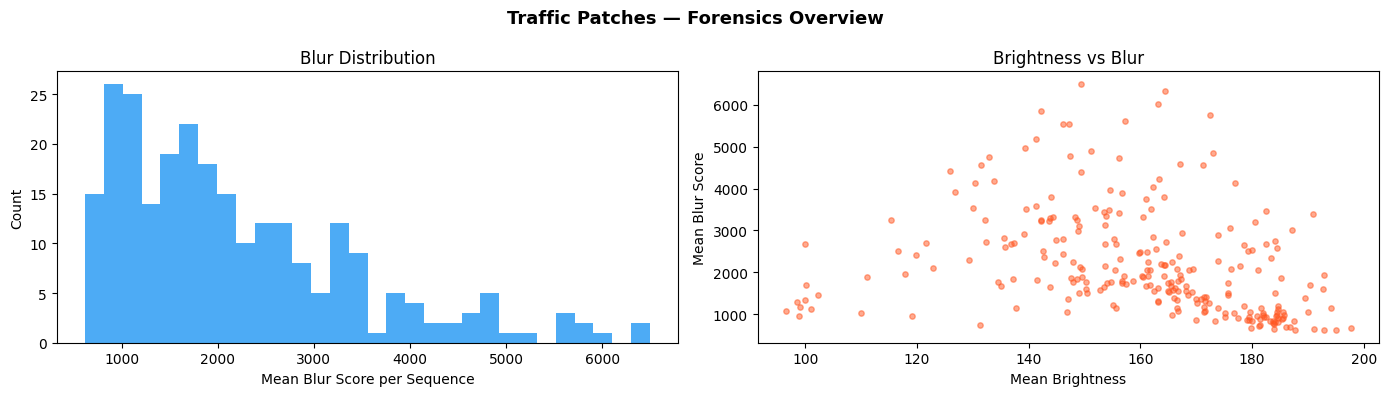

Step 2 complete


In [13]:
# Traffic patch forensics overview

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Traffic Patches — Forensics Overview", fontsize=13, fontweight='bold')

axes[0].hist(traffic_df["blur_mean"], bins=30, color="#2196F3", alpha=0.8)
axes[0].set_xlabel("Mean Blur Score per Sequence")
axes[0].set_ylabel("Count")
axes[0].set_title("Blur Distribution")

axes[1].scatter(traffic_df["brightness_mean"], traffic_df["blur_mean"],
                alpha=0.5, s=15, color="#FF5722")
axes[1].set_xlabel("Mean Brightness")
axes[1].set_ylabel("Mean Blur Score")
axes[1].set_title("Brightness vs Blur")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "step2_traffic_forensics.png", dpi=150, bbox_inches='tight')
plt.show()
print("Step 2 complete")

In [14]:
# Step 3: OCR Plate Extraction

def detect_plate_roi(img):
    gray    = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur    = cv2.GaussianBlur(gray, (5, 5), 0)
    edges   = cv2.Canny(blur, 50, 200)
    dilated = cv2.dilate(edges, np.ones((3, 3), np.uint8), iterations=1)

    contours, _ = cv2.findContours(dilated, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    contours     = sorted(contours, key=cv2.contourArea, reverse=True)[:20]

    h, w = img.shape[:2]
    for cnt in contours:
        x, y, cw, ch = cv2.boundingRect(cnt)
        aspect     = cw / (ch + 1e-6)
        area_ratio = (cw * ch) / (w * h)
        if 2.0 < aspect < 6.0 and 0.005 < area_ratio < 0.15:
            return img[y:y+ch, x:x+cw], (x, y, cw, ch)
    return None, None

def run_ocr_on_roi(img):
    roi, bbox = detect_plate_roi(img)
    target    = roi if (roi is not None and roi.size > 0) else img
    source    = "roi" if roi is not None else "full"

    gray     = cv2.cvtColor(target, cv2.COLOR_BGR2GRAY)
    resized  = cv2.resize(gray, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)
    _, thresh = cv2.threshold(resized, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    try:
        cfg  = "--psm 8 -c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789"
        data = pytesseract.image_to_data(thresh, config=cfg,
                                          output_type=pytesseract.Output.DICT)
        confs     = [c for c in data["conf"] if c != -1]
        texts     = [t.strip() for t in data["text"] if t.strip()]
        avg_conf  = float(np.mean(confs)) if confs else 0.0
        full_text = "".join(texts).upper().strip()
        return full_text, round(avg_conf, 1), source, bbox
    except Exception:
        return "", 0.0, source, None

# Run on all original train truck images
train_truck_imgs = [
    f for f in (YOLO_TRAIN / "truck").glob("*.jpg") if "_aug" not in f.stem
]

ocr_records = []
for p in train_truck_imgs:
    img = cv2.imread(str(p))
    if img is None:
        continue
    text, conf, source, bbox = run_ocr_on_roi(img)
    ocr_records.append({
        "filename": p.name, "ocr_text": text, "ocr_conf": conf,
        "source": source, "has_bbox": bbox is not None,
    })

ocr_df = pd.DataFrame(ocr_records)
n_roi  = (ocr_df["source"] == "roi").sum()
print(f"OCR complete — {len(ocr_df)} images")
print(f"Plate ROI detected: {n_roi} / {len(ocr_df)} ({100*n_roi/len(ocr_df):.1f}%)")
print(ocr_df[["filename","ocr_text","ocr_conf","source"]].head(8).to_string(index=False))

OCR complete — 393 images
Plate ROI detected: 225 / 393 (57.3%)
        filename ocr_text  ocr_conf source
076DHCYL41NC.jpg                0.0    roi
0AY7ZWSHSRN7.jpg        M       0.0    roi
0BT74OP6NOEG.jpg        A      18.0   full
0I4CVEE7B8WE.jpg        A      46.0   full
0NPSNPZWA2K0.jpg        2      16.0   full
0NVTVV54ATOT.jpg                0.0    roi
0OL2P2SQPI5P.jpg                0.0   full
0P9W2B8TWYU9.jpg                0.0    roi


In [15]:
# Flag low-confidence and empty OCR results

OCR_CONF_THRESHOLD = 20.0

ocr_df["empty_text"]  = ocr_df["ocr_text"].str.len() == 0
ocr_df["low_conf"]    = ocr_df["ocr_conf"] < OCR_CONF_THRESHOLD
ocr_df["no_roi"]      = ~ocr_df["has_bbox"]
ocr_df["ocr_anomaly"] = ocr_df["empty_text"] | ocr_df["low_conf"]

n_empty  = ocr_df["empty_text"].sum()
n_low    = ocr_df["low_conf"].sum()
n_no_roi = ocr_df["no_roi"].sum()
n_flagged = ocr_df["ocr_anomaly"].sum()

print(f"No plate region : {n_no_roi}  / {len(ocr_df)} ({100*n_no_roi/len(ocr_df):.1f}%)")
print(f"Empty OCR text  : {n_empty}  / {len(ocr_df)}")
print(f"Low confidence  : {n_low}  / {len(ocr_df)}")
print(f"Total flagged   : {n_flagged} / {len(ocr_df)} ({100*n_flagged/len(ocr_df):.1f}%)")
print()
print("Note: high flag rate is expected — YOLO dataset uses generic truck photos,")
print("not dedicated plate images. Unreadable plates are treated as suspicious in the ensemble.")

No plate region : 168  / 393 (42.7%)
Empty OCR text  : 293  / 393
Low confidence  : 374  / 393
Total flagged   : 374 / 393 (95.2%)

Note: high flag rate is expected — YOLO dataset uses generic truck photos,
not dedicated plate images. Unreadable plates are treated as suspicious in the ensemble.


In [16]:
# Cross-reference OCR text against delivery trucks registry

trucks_csv = pd.read_csv("../Delivery truck trips data/delivery_trucks_cleaned.csv", dtype=str)
known_ids  = set(trucks_csv["vehicle_id"].str.upper().str.strip().dropna())

print(f"Registry loaded — {len(known_ids)} known vehicle IDs")
print(f"Sample IDs: {list(known_ids)[:5]}")

def check_registry(text):
    if not text:
        return False
    return any(token in known_ids for token in text.split())

ocr_df["registry_match"] = ocr_df["ocr_text"].apply(check_registry)
n_match = ocr_df["registry_match"].sum()
print(f"Registry matches: {n_match} / {len(ocr_df)} ({100*n_match/len(ocr_df):.1f}%)")
print("Note: 0 matches expected — YOLO dataset and delivery CSV are unrelated sources.")

Registry loaded — 1159 known vehicle IDs
Sample IDs: ['GJ06AZ6152', 'PB65AR0273', 'RJ14GL2988', 'HR55AH2713', 'JH01BC5813']
Registry matches: 0 / 393 (0.0%)
Note: 0 matches expected — YOLO dataset and delivery CSV are unrelated sources.


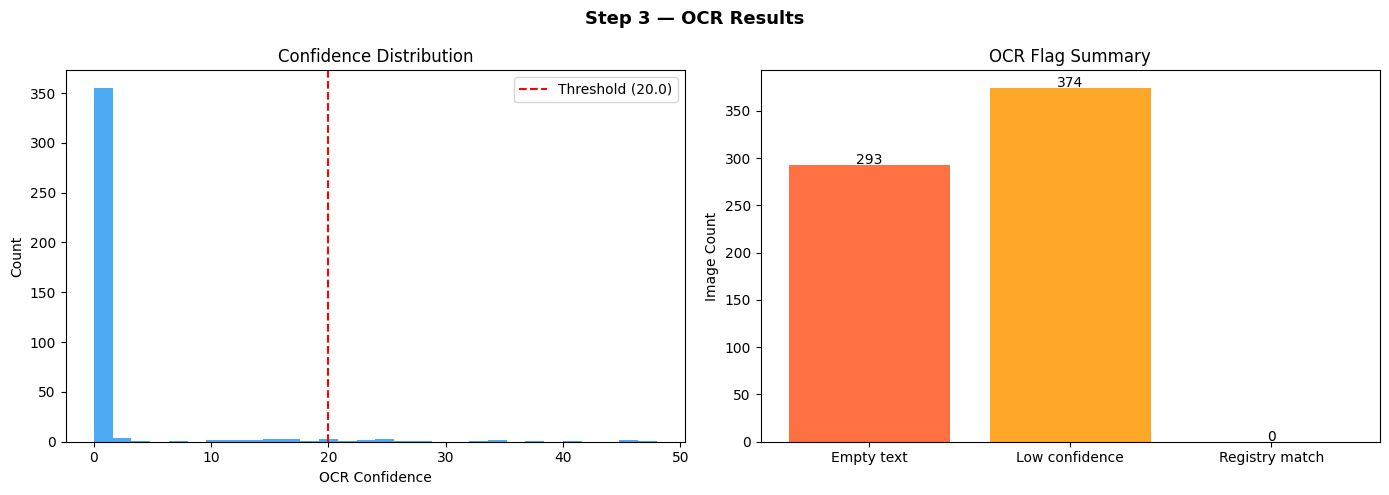

In [17]:
# OCR confidence distribution and flag summary

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Step 3 — OCR Results", fontsize=13, fontweight='bold')

axes[0].hist(ocr_df["ocr_conf"], bins=30, color="#2196F3", alpha=0.8)
axes[0].axvline(OCR_CONF_THRESHOLD, color="red", linestyle="--",
                label=f"Threshold ({OCR_CONF_THRESHOLD})")
axes[0].set_xlabel("OCR Confidence")
axes[0].set_ylabel("Count")
axes[0].set_title("Confidence Distribution")
axes[0].legend()

categories = ["Empty text", "Low confidence", "Registry match"]
counts     = [n_empty, n_low, n_match]
colors_bar = ["#FF5722", "#FF9800", "#4CAF50"]
axes[1].bar(categories, counts, color=colors_bar, alpha=0.85)
axes[1].set_ylabel("Image Count")
axes[1].set_title("OCR Flag Summary")
for bar, count in zip(axes[1].patches, counts):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 str(count), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "step3_ocr_results.png", dpi=150, bbox_inches='tight')
plt.show()

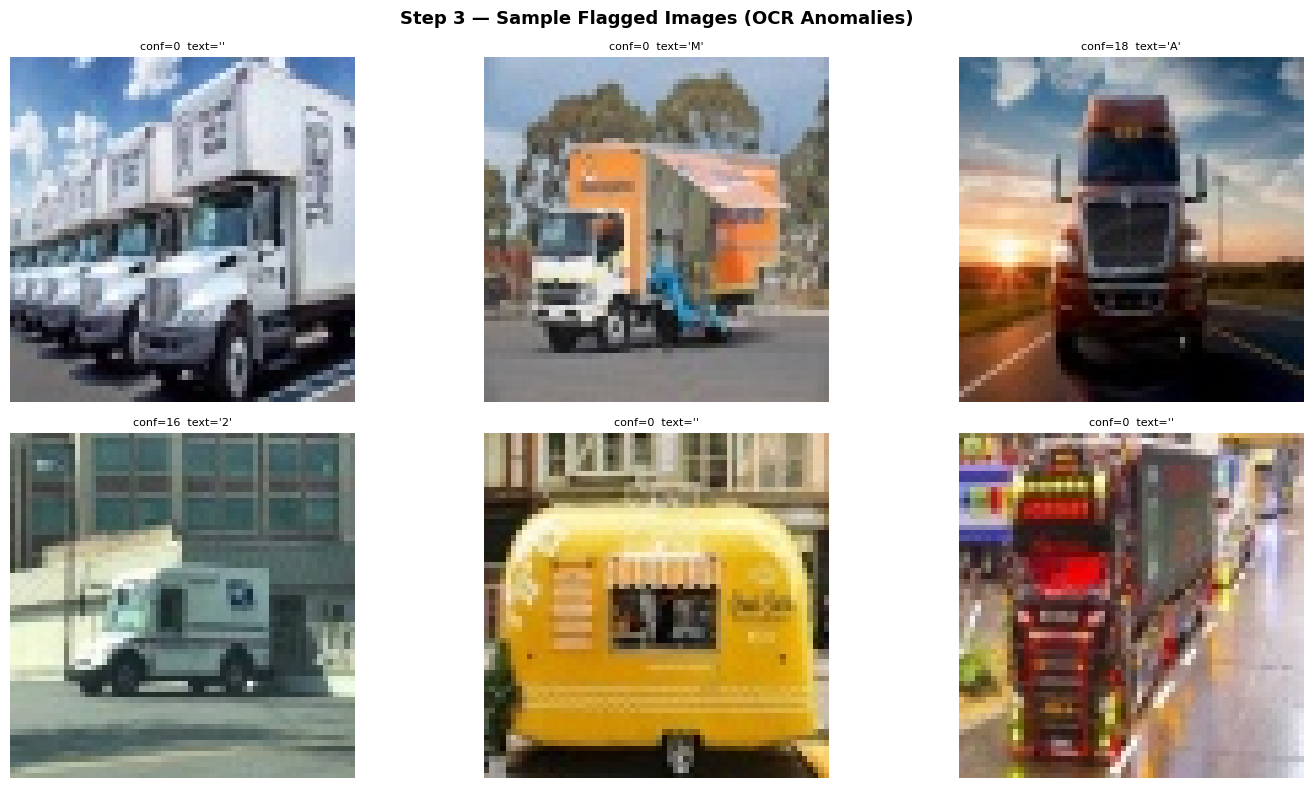

Step 3 complete


In [18]:
# Sample flagged images with OCR output

flagged_imgs = ocr_df[ocr_df["ocr_anomaly"]].head(6)

if len(flagged_imgs) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle("Step 3 — Sample Flagged Images (OCR Anomalies)", fontsize=13, fontweight='bold')
    axes = axes.flatten()

    for ax, (_, row) in zip(axes, flagged_imgs.iterrows()):
        img = cv2.imread(str(YOLO_TRAIN / "truck" / row["filename"]))
        if img is None:
            ax.axis("off")
            continue
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.set_title(f"conf={row['ocr_conf']:.0f}  text='{row['ocr_text'][:20]}'", fontsize=8)
        ax.axis("off")

    for ax in axes[len(flagged_imgs):]:
        ax.axis("off")

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "step3_flagged_samples.png", dpi=150, bbox_inches='tight')
    plt.show()

print("Step 3 complete")

In [19]:
# Step 4: CNN Classifier (MobileNetV2)
# Data generators — classes explicitly set to exclude .ipynb_checkpoints

IMG_SIZE   = (224, 224)
BATCH_SIZE = 16
VALID_CLASSES = ["truck", "vehicle truck"]

train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    horizontal_flip=True, zoom_range=0.1, rotation_range=10,
)
val_gen  = ImageDataGenerator(preprocessing_function=preprocess_input)
test_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_ds = train_gen.flow_from_directory(
    str(YOLO_TRAIN), target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="binary", classes=VALID_CLASSES, shuffle=True, seed=42
)
val_ds = val_gen.flow_from_directory(
    str(YOLO_VAL), target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="binary", classes=VALID_CLASSES, shuffle=False
)
test_ds = test_gen.flow_from_directory(
    str(YOLO_TEST), target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="binary", classes=VALID_CLASSES, shuffle=False
)

print(f"Class indices : {train_ds.class_indices}")
print(f"Train: {train_ds.samples} | Val: {val_ds.samples} | Test: {test_ds.samples}")

Found 728 images belonging to 2 classes.
Found 189 images belonging to 2 classes.
Found 85 images belonging to 2 classes.
Class indices : {'truck': 0, 'vehicle truck': 1}
Train: 728 | Val: 189 | Test: 85


In [20]:
# Build MobileNetV2 classifier — frozen base + custom head

base = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights="imagenet")
for layer in base.layers:
    layer.trainable = False

x   = base.output
x   = layers.GlobalAveragePooling2D()(x)
x   = layers.Dense(128, activation="relu")(x)
x   = layers.Dropout(0.4)(x)
out = layers.Dense(1, activation="sigmoid")(x)

model = models.Model(base.input, out)
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
print(f"Trainable params: {sum(w.numpy().size for w in model.trainable_weights):,}")

Trainable params: 164,097


In [21]:
# Compute class weights to handle imbalance, then train

labels       = train_ds.classes
cw           = compute_class_weight("balanced", classes=np.unique(labels), y=labels)
class_weight = {i: float(w) for i, w in enumerate(cw)}
print(f"Class weights: truck={class_weight[0]:.3f}, vehicle truck={class_weight[1]:.3f}")

callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1,
)
print("Training complete")

Class weights: truck=0.549, vehicle truck=5.600
Epoch 1/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 19s 340ms/step - accuracy: 0.5708 - loss: 1.1206 - val_accuracy: 0.1905 - val_loss: 1.2513 - learning_rate: 0.0010
Epoch 2/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 14s 303ms/step - accuracy: 0.5130 - loss: 0.7352 - val_accuracy: 0.9312 - val_loss: 0.3960 - learning_rate: 0.0010
Epoch 3/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 14s 295ms/step - accuracy: 0.6254 - loss: 0.6031 - val_accuracy: 0.7566 - val_loss: 0.5375 - learning_rate: 0.0010
Epoch 4/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 14s 293ms/step - accuracy: 0.7065 - loss: 0.5705 - val_accuracy: 0.8730 - val_loss: 0.3928 - learning_rate: 0.0010
Epoch 5/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 14s 298ms/step - accuracy: 0.7987 - loss: 0.5350 - val_accuracy: 0.8042 - val_loss: 0.4968 - learning_rate: 0.0010
Epoch 6/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 14s 294ms/step - accuracy: 0.7261 - loss: 0.4959 - val_accuracy: 0.9312 - val_loss: 0.2638 - learning_rate: 0.0010
Epoch 7/20
46/46 ━━━━━━━━━━━━━━━━━

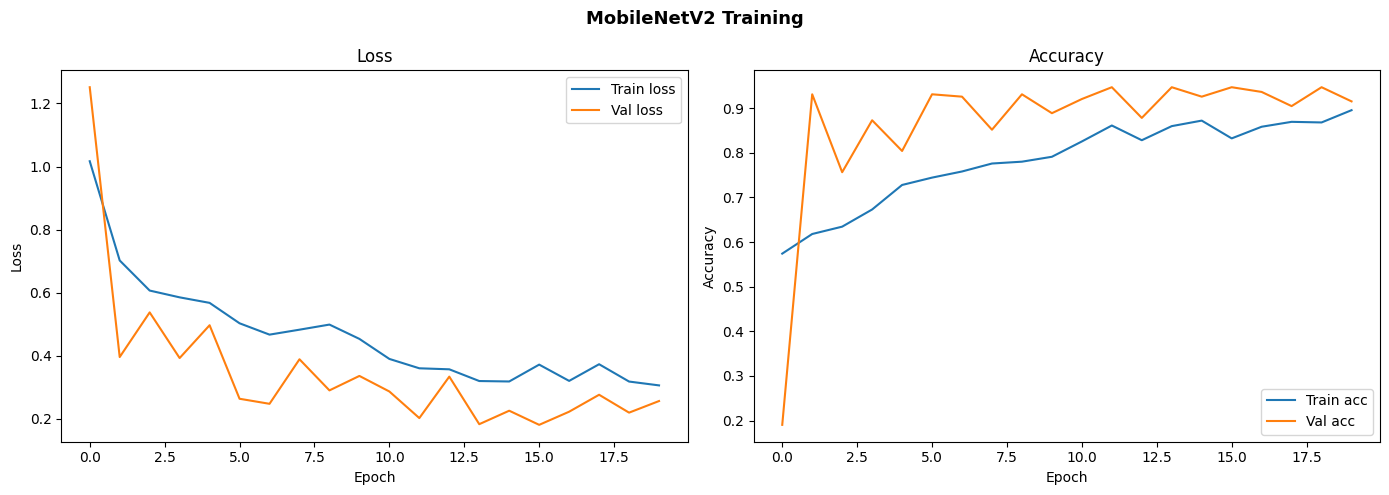

In [22]:
# Training loss and accuracy curves

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("MobileNetV2 Training", fontsize=13, fontweight='bold')

axes[0].plot(history.history["loss"],     label="Train loss")
axes[0].plot(history.history["val_loss"], label="Val loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Loss"); axes[0].legend()

axes[1].plot(history.history["accuracy"],     label="Train acc")
axes[1].plot(history.history["val_accuracy"], label="Val acc")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy"); axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "step4_training_curves.png", dpi=150, bbox_inches='tight')
plt.show()

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 309ms/step

Classification Report:
               precision    recall  f1-score   support

        truck       0.95      0.96      0.96        79
vehicle truck       0.40      0.33      0.36         6

     accuracy                           0.92        85
    macro avg       0.68      0.65      0.66        85
 weighted avg       0.91      0.92      0.91        85



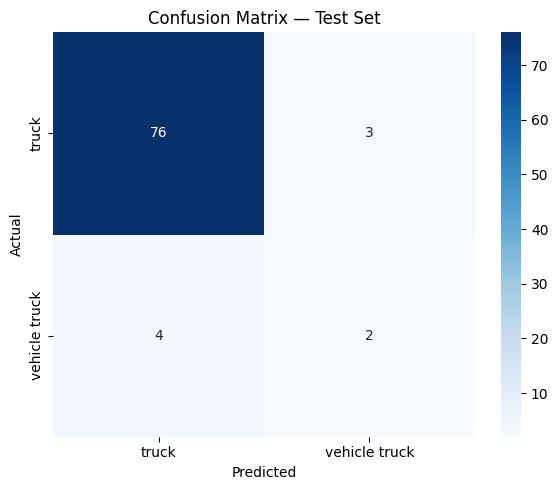

In [23]:
# Evaluate on test set — classification report + confusion matrix

test_ds.reset()
y_prob = model.predict(test_ds, verbose=1).flatten()
y_pred = (y_prob >= 0.5).astype(int)
y_true = test_ds.classes

class_names = list(test_ds.class_indices.keys())
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

cm  = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix — Test Set")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "step4_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

In [24]:
# Save model and attach CNN scores to OCR dataframe

model.save(str(OUTPUT_DIR / "mobilenetv2_truck_classifier.keras"))
print("Model saved")

def predict_image(img_path):
    img = load_img(str(img_path), target_size=IMG_SIZE)
    arr = preprocess_input(img_to_array(img)[np.newaxis, ...])
    return float(model.predict(arr, verbose=0)[0, 0])

cnn_scores = [predict_image(p) for p in train_truck_imgs]
ocr_df["cnn_score"] = cnn_scores

print(f"CNN scores — mean={np.mean(cnn_scores):.3f}, max={np.max(cnn_scores):.3f}, min={np.min(cnn_scores):.3f}")
print(ocr_df[["filename","ocr_conf","cnn_score"]].head(8).to_string(index=False))
print("Step 4 complete")

Model saved
CNN scores — mean=0.083, max=0.775, min=0.000
        filename  ocr_conf  cnn_score
076DHCYL41NC.jpg       0.0   0.020173
0AY7ZWSHSRN7.jpg       0.0   0.188224
0BT74OP6NOEG.jpg      18.0   0.108427
0I4CVEE7B8WE.jpg      46.0   0.025640
0NPSNPZWA2K0.jpg      16.0   0.004001
0NVTVV54ATOT.jpg       0.0   0.048967
0OL2P2SQPI5P.jpg       0.0   0.068802
0P9W2B8TWYU9.jpg       0.0   0.178494
Step 4 complete


In [25]:
# Step 5: Ensemble Scoring
# Merge OCR, CNN, and forensics signals into one suspicion score

ocr_df["ocr_score"] = 1.0 - (ocr_df["ocr_conf"] / 100.0).clip(0, 1)

forensics_cols = truck_df[truck_df["split"] == "train"][
    ["filename", "blur_flag", "noise_flag", "anomaly"]
].copy()
forensics_cols.columns = ["filename", "blur_flag", "noise_flag", "forensics_flag"]

ocr_df = ocr_df.merge(forensics_cols, on="filename", how="left")
ocr_df["forensics_flag"] = ocr_df["forensics_flag"].fillna(False)

# Weighted ensemble (OCR 25%, CNN 55%, forensics 20%)
W_OCR, W_CNN, W_FORENSICS = 0.25, 0.55, 0.20
ocr_df["forensics_score"] = ocr_df["forensics_flag"].astype(float)
ocr_df["suspicion_score"] = (
    W_OCR * ocr_df["ocr_score"] +
    W_CNN * ocr_df["cnn_score"] +
    W_FORENSICS * ocr_df["forensics_score"]
)

def risk_tier(score):
    if score >= 0.6:  return "HIGH"
    if score >= 0.35: return "MEDIUM"
    return "LOW"

ocr_df["risk"] = ocr_df["suspicion_score"].apply(risk_tier)

print("Suspicion score stats:")
print(ocr_df["suspicion_score"].describe().round(3))
print()
print("Risk tier counts:")
print(ocr_df["risk"].value_counts())

Suspicion score stats:
count    393.000
mean       0.297
std        0.076
min        0.136
25%        0.256
50%        0.270
75%        0.310
max        0.676
Name: suspicion_score, dtype: float64

Risk tier counts:
risk
LOW       332
MEDIUM     57
HIGH        4
Name: count, dtype: int64


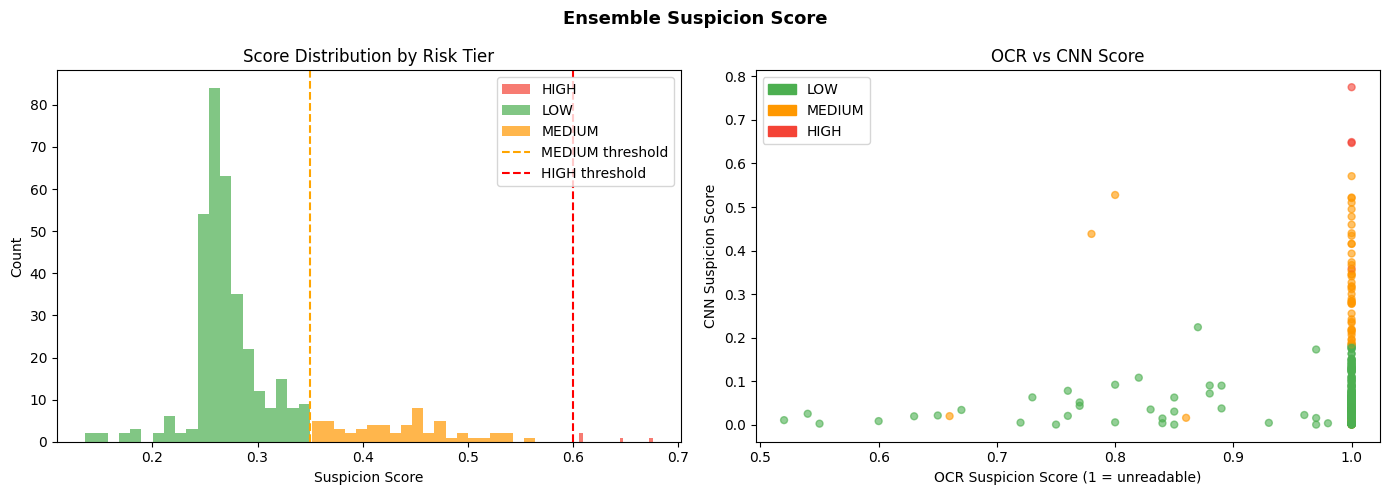

In [26]:
# Suspicion score distribution and OCR vs CNN scatter

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Ensemble Suspicion Score", fontsize=13, fontweight='bold')

colors = {"LOW": "#4CAF50", "MEDIUM": "#FF9800", "HIGH": "#F44336"}

for tier, grp in ocr_df.groupby("risk"):
    axes[0].hist(grp["suspicion_score"], bins=20, alpha=0.7, label=tier, color=colors[tier])
axes[0].axvline(0.35, color="orange", linestyle="--", label="MEDIUM threshold")
axes[0].axvline(0.60, color="red",    linestyle="--", label="HIGH threshold")
axes[0].set_xlabel("Suspicion Score"); axes[0].set_ylabel("Count")
axes[0].set_title("Score Distribution by Risk Tier"); axes[0].legend()

tier_colors = ocr_df["risk"].map(colors)
axes[1].scatter(ocr_df["ocr_score"], ocr_df["cnn_score"], c=tier_colors, alpha=0.6, s=25)
axes[1].set_xlabel("OCR Suspicion Score (1 = unreadable)")
axes[1].set_ylabel("CNN Suspicion Score")
axes[1].set_title("OCR vs CNN Score")
patches = [mpatches.Patch(color=c, label=t) for t, c in colors.items()]
axes[1].legend(handles=patches)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "step5_suspicion_scores.png", dpi=150, bbox_inches='tight')
plt.show()

In [27]:
# Top 15 most suspicious images

top = ocr_df.sort_values("suspicion_score", ascending=False).head(15)
print(top[["filename","ocr_conf","cnn_score","forensics_flag",
           "suspicion_score","risk"]].to_string(index=False))

        filename  ocr_conf  cnn_score  forensics_flag  suspicion_score   risk
9DG0UQ1QF468.jpg       0.0   0.775084           False         0.676296   HIGH
N41Q4ZU2ELB5.jpg       0.0   0.358461            True         0.647153   HIGH
DH1ROXTXT346.jpg       0.0   0.649284           False         0.607106   HIGH
CGBQCAEA3IBW.jpg       0.0   0.647008           False         0.605854   HIGH
YVNT7TM7XGIS.jpg       0.0   0.570973           False         0.564035 MEDIUM
FF4TRJUXII0Z.jpg       0.0   0.522015           False         0.537108 MEDIUM
GX6TITVKPL57.jpg       0.0   0.520677           False         0.536372 MEDIUM
QDW2Q2NTCATN.jpg       0.0   0.510103           False         0.530556 MEDIUM
G4315Y4ZLH0Q.jpg       0.0   0.495122           False         0.522317 MEDIUM
DY3QEEY19DMJ.jpg       0.0   0.478160           False         0.512988 MEDIUM
KR1PVTABAKQF.jpg       0.0   0.459637           False         0.502800 MEDIUM
34EIPVG6QZ3H.jpg       0.0   0.440027           False         0.

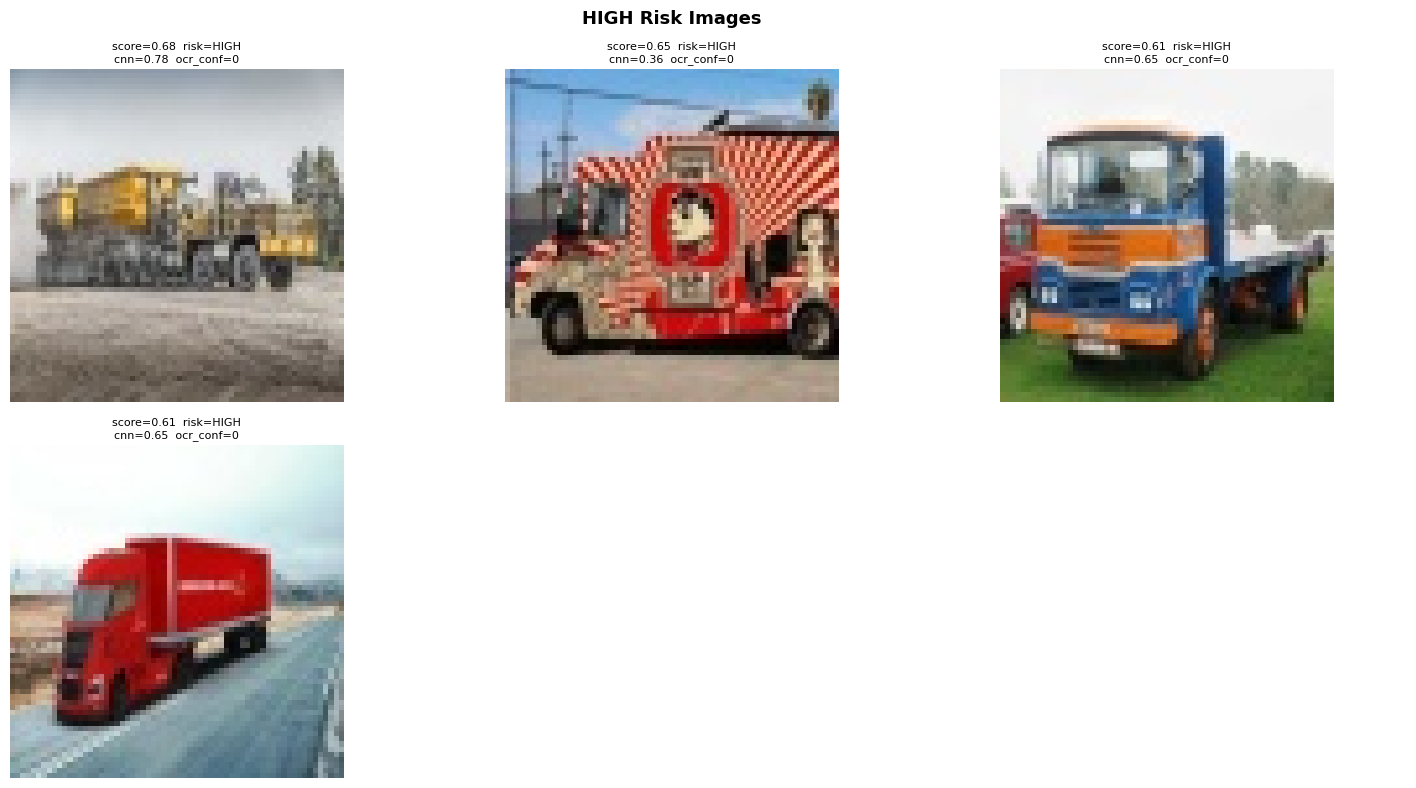

Step 5 complete


In [28]:
# HIGH risk image gallery

high_risk = ocr_df[ocr_df["risk"] == "HIGH"].sort_values(
    "suspicion_score", ascending=False).head(6)

if len(high_risk) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle("HIGH Risk Images", fontsize=13, fontweight='bold')
    axes = axes.flatten()

    for ax, (_, row) in zip(axes, high_risk.iterrows()):
        img = cv2.imread(str(YOLO_TRAIN / "truck" / row["filename"]))
        if img is None:
            ax.axis("off")
            continue
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.set_title(
            f"score={row['suspicion_score']:.2f}  risk={row['risk']}\n"
            f"cnn={row['cnn_score']:.2f}  ocr_conf={row['ocr_conf']:.0f}",
            fontsize=8
        )
        ax.axis("off")

    for ax in axes[len(high_risk):]:
        ax.axis("off")

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "step5_high_risk_images.png", dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No HIGH risk images found.")

print("Step 5 complete")

In [29]:
# Smoke test — src/forgery_check.py

spec = importlib.util.spec_from_file_location("forgery_check", "../src/forgery_check.py")
fc   = importlib.util.module_from_spec(spec)
spec.loader.exec_module(fc)

test_imgs = list((YOLO_TRAIN / "truck").glob("*.jpg"))[:3]
for p in test_imgs:
    result = fc.check_vehicle(p)
    print(f"{result['image_path'].split(chr(92))[-1]:25s} "
          f"risk={result['risk_level']:6s}  "
          f"score={result['suspicion_score']:.3f}  "
          f"cnn={result['cnn_score']:.3f}  "
          f"ocr_conf={result['ocr_conf']:.0f}")

print("\nforgery_check.py works correctly")

076DHCYL41NC.jpg          risk=MEDIUM  score=0.407  cnn=0.286  ocr_conf=0
076DHCYL41NC_aug.jpg      risk=MEDIUM  score=0.509  cnn=0.108  ocr_conf=0
0AY7ZWSHSRN7.jpg          risk=LOW     score=0.299  cnn=0.089  ocr_conf=0

forgery_check.py works correctly


In [30]:
# Create data/licenses/ folder structure
LICENSES_DIR         = Path("../data/licenses")
GENUINE_DIR          = LICENSES_DIR / "genuine"
FORGED_DIR           = LICENSES_DIR / "forged"

GENUINE_DIR.mkdir(parents=True, exist_ok=True)
FORGED_DIR.mkdir(parents=True, exist_ok=True)

print(f"Folders created:")
print(f"  {GENUINE_DIR}")
print(f"  {FORGED_DIR}")

Folders created:
  ..\data\licenses\genuine
  ..\data\licenses\forged


In [31]:
# Synthetic license generator using OpenCV

def make_license(
    name, license_no, dob, expiry,
    vehicle_class="B", bg_color=(240, 240, 220)
):
    """Draw a synthetic driver's license image (400x250 px)."""
    img = np.full((250, 400, 3), bg_color, dtype=np.uint8)

    # Border
    cv2.rectangle(img, (5, 5), (395, 245), (0, 0, 180), 3)

    # Header bar
    cv2.rectangle(img, (5, 5), (395, 45), (0, 0, 180), -1)
    cv2.putText(img, "DRIVER'S LICENSE", (80, 32),
                cv2.FONT_HERSHEY_SIMPLEX, 0.75, (255, 255, 255), 2)

    # Photo placeholder
    cv2.rectangle(img, (15, 55), (110, 180), (180, 180, 180), -1)
    cv2.rectangle(img, (15, 55), (110, 180), (100, 100, 100), 2)
    cv2.putText(img, "PHOTO", (32, 125),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (80, 80, 80), 1)

    # Fields
    fields = [
        ("NAME",    name,          (125, 80)),
        ("LIC NO",  license_no,    (125, 110)),
        ("DOB",     dob,           (125, 140)),
        ("EXPIRY",  expiry,        (125, 170)),
        ("CLASS",   vehicle_class, (125, 200)),
    ]
    for label, value, pos in fields:
        cv2.putText(img, f"{label}:", pos,
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, (60, 60, 60), 1)
        cv2.putText(img, value, (pos[0] + 80, pos[1]),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 0, 0), 1)

    # Barcode strip at bottom
    cv2.rectangle(img, (15, 210), (385, 235), (30, 30, 30), -1)
    for x in range(15, 385, 4):
        if x % 8 == 0:
            cv2.line(img, (x, 210), (x, 235), (220, 220, 220), 1)

    return img


def forge_license(genuine_img, method="noise"):
    """
    Create a forged version of a license image.
    method: 'noise' | 'blur' | 'crop' | 'tamper'
    """
    forged = genuine_img.copy()

    if method == "noise":
        # Add heavy salt-and-pepper noise (simulates scan artifact)
        noise = np.random.randint(0, 80, forged.shape, dtype=np.uint8)
        forged = cv2.add(forged, noise)

    elif method == "blur":
        # Heavy blur (simulates low-quality photocopy)
        forged = cv2.GaussianBlur(forged, (15, 15), 0)

    elif method == "crop":
        # Misaligned crop and paste (simulates cut-and-paste forgery)
        h, w = forged.shape[:2]
        forged = forged[10:h, 5:w]
        forged = cv2.copyMakeBorder(forged, 0, 10, 0, 5,
                                     cv2.BORDER_CONSTANT, value=(200, 200, 200))

    elif method == "tamper":
        # Black rectangle over name field (simulates text tampering)
        cv2.rectangle(forged, (205, 65), (385, 90), (0, 0, 0), -1)
        cv2.putText(forged, "JOHN MODIFIED", (210, 83),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 255), 1)

    return forged


print("License generators defined")

License generators defined


In [32]:
# Generate 20 genuine + 20 forged synthetic licenses

import random, string

def rand_lic_no():
    letters = ''.join(random.choices(string.ascii_uppercase, k=2))
    digits  = ''.join(random.choices(string.digits, k=7))
    return f"{letters}{digits}"

def rand_date(start_year=1970, end_year=2000):
    y = random.randint(start_year, end_year)
    m = random.randint(1, 12)
    d = random.randint(1, 28)
    return f"{d:02d}/{m:02d}/{y}"

FIRST_NAMES = ["Juan", "Maria", "Jose", "Ana", "Carlos",
               "Rosa", "Miguel", "Elena", "Pedro", "Sofia"]
LAST_NAMES  = ["Santos", "Reyes", "Cruz", "Garcia", "Lopez",
               "Mendoza", "Torres", "Flores", "Ramos", "Diaz"]
FORGE_METHODS = ["noise", "blur", "crop", "tamper"]

genuine_paths = []
forged_paths  = []

random.seed(42)

for i in range(20):
    name    = f"{random.choice(FIRST_NAMES)} {random.choice(LAST_NAMES)}"
    lic_no  = rand_lic_no()
    dob     = rand_date(1970, 2000)
    expiry  = rand_date(2025, 2030)
    vclass  = random.choice(["A", "B", "C"])

    # Genuine
    img     = make_license(name, lic_no, dob, expiry, vclass)
    g_path  = GENUINE_DIR / f"license_{i+1:03d}.jpg"
    cv2.imwrite(str(g_path), img)
    genuine_paths.append(g_path)

    # Forged — apply one of 4 tampering methods
    method  = FORGE_METHODS[i % len(FORGE_METHODS)]
    forged  = forge_license(img, method=method)
    f_path  = FORGED_DIR / f"license_{i+1:03d}_forged_{method}.jpg"
    cv2.imwrite(str(f_path), forged)
    forged_paths.append(f_path)

print(f"Generated {len(genuine_paths)} genuine licenses -> {GENUINE_DIR}")
print(f"Generated {len(forged_paths)} forged  licenses -> {FORGED_DIR}")

Generated 20 genuine licenses -> ..\data\licenses\genuine
Generated 20 forged  licenses -> ..\data\licenses\forged


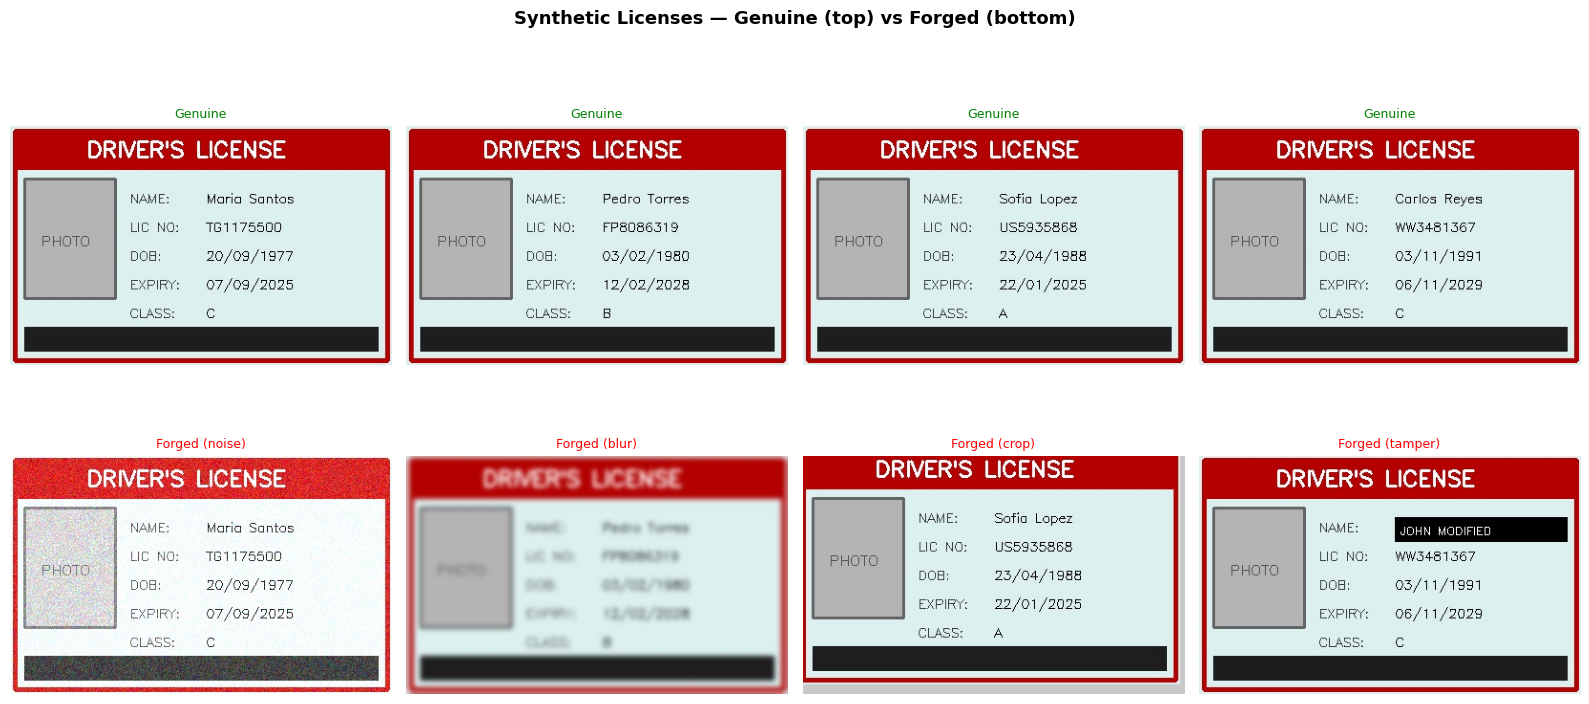

Folder structure:
  data/licenses/genuine/  — 20 images
  data/licenses/forged/   — 20 images


In [34]:
# Preview — 4 genuine + their forged counterparts

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Synthetic Licenses — Genuine (top) vs Forged (bottom)",
             fontsize=13, fontweight='bold')

for col in range(4):
    g_img = cv2.imread(str(genuine_paths[col]))
    f_img = cv2.imread(str(forged_paths[col]))

    axes[0][col].imshow(cv2.cvtColor(g_img, cv2.COLOR_BGR2RGB))
    axes[0][col].set_title("Genuine", fontsize=9, color="green")
    axes[0][col].axis("off")

    axes[1][col].imshow(cv2.cvtColor(f_img, cv2.COLOR_BGR2RGB))
    method = FORGE_METHODS[col]
    axes[1][col].set_title(f"Forged ({method})", fontsize=9, color="red")
    axes[1][col].axis("off")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "licenses_preview.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"Folder structure:")
print(f"  data/licenses/genuine/  — {len(list(GENUINE_DIR.glob('*.jpg')))} images")
print(f"  data/licenses/forged/   — {len(list(FORGED_DIR.glob('*.jpg')))} images")